In [87]:
import stim

from spidercat.utils import qasm_to_stim
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp
from spiderstate.stim_utils import get_circuit_depth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
code = "17_1_5"
max_col_ops = 100

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="Z"
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")
print("Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.")

Loading QECC: 17_1_5
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100)...
Computing initial single faults...

Running verification stabilizers search for t=2 layers (top_n=50, first_layer=Z)...

--- Z Faults Verification (Non-FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 20.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 20.0
Injected 10 X faults into X-verification pool.

--- X Faults Verification (FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 32.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 32.0

Synthesizing Z fault verification circuits...

Synthesizing X fault verification circuits...

--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 29
Num CX: 71
Total instructions: 85
Depth: 33
Circuit output omitted to avoid terminal spam. You can export or pr

Num CX: 71


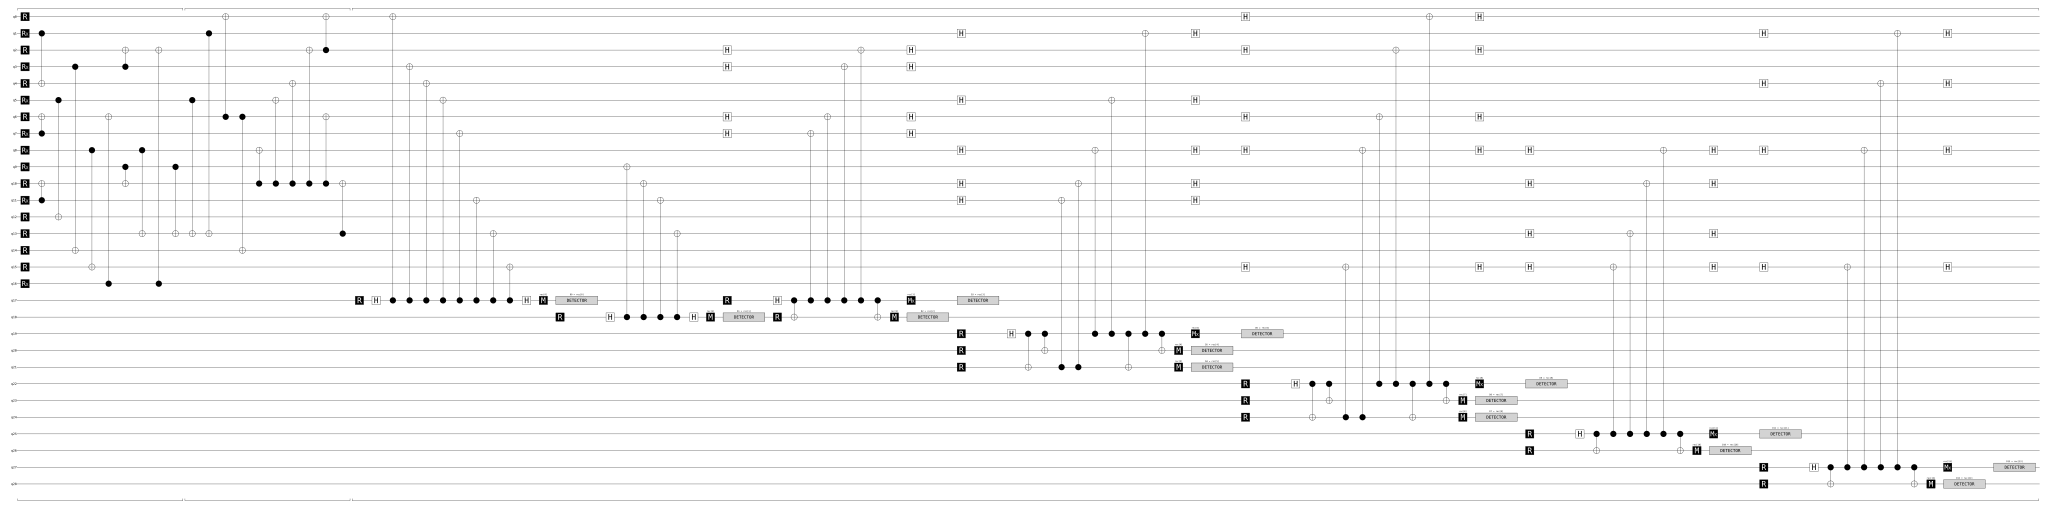

In [125]:
print(f"Num CX: {count_operations(final_circ)[0]}")

final_circ.diagram('timeline-svg')

In [126]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print((meas_samples @ L_z.T % 2).T)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[[0 0 0 0 0]]


In [127]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_z, L_primary=np.atleast_2d(L_z),
        H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
        d=d, t=d // 2,
        primary_basis="Z", conjugate_basis="X",
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis (d=5, t=2)...
    [PASS] UNSAT. The state preparation is strictly Fault-Tolerant.

  [Conjugate] Evaluating X-basis via Combinatorics (t=2)...
    [PASS] No uncorrectable conjugate cascades found.
Verification Result: True


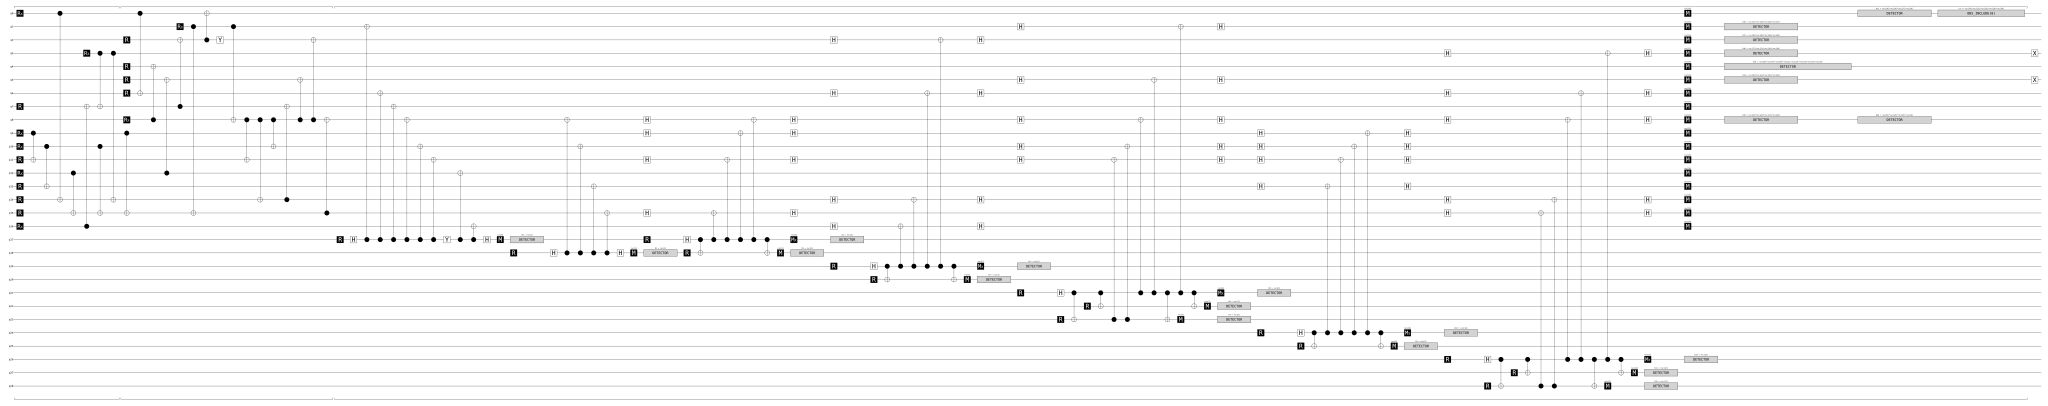

In [122]:
res_exhaustive.diagram("timeline-svg")

In [60]:
if True:
    file = get_project_root().joinpath("good_circuits", f"{code}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

In [66]:
bens_circ = qasm_to_stim("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[26];
creg c[9];
h q[25];
h q[20];
h q[21];
h q[17];
h q[0];
h q[3];
h q[5];
h q[9];
h q[10];
h q[11];
h q[12];
h q[13];
cx q[17], q[23];
cx q[20], q[18];
cx q[21], q[19];
cx q[5], q[7];
cx q[12], q[15];
cx q[11], q[14];
cx q[10], q[8];
cx q[0], q[2];
cx q[12], q[6];
cx q[3], q[7];
cx q[15], q[4];
cx q[10], q[16];
cx q[9], q[11];
cx q[16], q[24];
cx q[12], q[14];
cx q[13], q[7];
cx q[8], q[15];
cx q[6], q[1];
cx q[0], q[3];
cx q[4], q[2];
cx q[9], q[10];
cx q[25], q[13];
cx q[25], q[3];
cx q[12], q[22];
cx q[4], q[24];
cx q[15], q[18];
cx q[2], q[19];
cx q[17], q[0];
cx q[11], q[8];
cx q[14], q[16];
cx q[7], q[6];
cx q[1], q[22];
cx q[5], q[4];
cx q[13], q[12];
cx q[15], q[24];
cx q[14], q[18];
cx q[17], q[10];
cx q[3], q[1];
cx q[5], q[19];
cx q[10], q[18];
measure q[22] -> c[0];
measure q[24] -> c[1];
cx q[13], q[19];
cx q[17], q[1];
cx q[1], q[19];
cx q[17], q[11];
cx q[11], q[18];
cx q[17], q[4];
cx q[20], q[18];
cx q[17], q[16];
measure q[18] -> c[2];
cx q[17], q[7];
h q[20];
measure q[20] -> c[3];
cx q[7], q[19];
cx q[17], q[12];
cx q[17], q[23];
cx q[21], q[19];
h q[17];
measure q[17] -> c[4];
measure q[19] -> c[5];
h q[21];
measure q[21] -> c[6];
measure q[23] -> c[7];
h q[25];
measure q[25] -> c[8];
""")
for i in range(bens_circ.num_measurements):
    bens_circ.append("DETECTOR", [stim.target_rec(-i-1)])


print(f"Num CX: {count_operations(bens_circ)[0]}")
print(f"Total instructions: {sum(count_operations(bens_circ))}")
print(f"Depth: {get_circuit_depth(bens_circ)}")
bens_circ.diagram("timeline-svg")

print(bens_circ)

Num CX: 53
Total instructions: 62
Depth: 16
H 25 20 21 17 0 3 5 9 10 11 12 13
CX 17 23 20 18 21 19 5 7 12 15 11 14 10 8 0 2 12 6 3 7 15 4 10 16 9 11 16 24 12 14 13 7 8 15 6 1 0 3 4 2 9 10 25 13 25 3 12 22 4 24 15 18 2 19 17 0 11 8 14 16 7 6 1 22 5 4 13 12 15 24 14 18 17 10 3 1 5 19 10 18
M 22 24
CX 13 19 17 1 1 19 17 11 11 18 17 4 20 18 17 16
M 18
CX 17 7
H 20
M 20
CX 7 19 17 12 17 23 21 19
H 17
M 17 19
H 21
M 21 23
H 25
M 25
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
DETECTOR rec[-4]
DETECTOR rec[-5]
DETECTOR rec[-6]
DETECTOR rec[-7]
DETECTOR rec[-8]
DETECTOR rec[-9]


In [51]:
x_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1]
])

z_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
])

z_logs_17_1_5 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ z_stabs_17_1_5.T % 2)
print(meas_samples @ z_logs_17_1_5.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[0 0 0 0 0 0 0 0 0 0]


In [128]:
print("\nRunning Fast DEM/SAT FT Verification...")
# res_exhaustive = verify_ftsp(
#     prep_circ=bens_circ,
#     H_primary=z_stabs_17_1_5, L_primary=np.atleast_2d(z_logs_17_1_5),
#     H_conjugate=z_stabs_17_1_5, L_conjugate=np.atleast_2d(z_logs_17_1_5),
#     d=5, t=2,
#     primary_basis="Z", conjugate_basis="X",
#     verbose=True
# )
res_exhaustive = stim.Circuit("""
RX 0 1
R 2 4
RX 5 8 9
R 10 11 12 13 14
RX 16 17
CX 17 13 0 2 1 4 8 10 9 11 5 12 16 14
R 3
RX 7 15
CX 0 3 1 13 15 10 9 17 7 14 5 17 7 3 15 17 17 13
MX 17
DETECTOR rec[-1]
TICK
R 6
CX 14 6
X 14
CX 10 12 14 2 10 9 10 4 10 3 3 14 10 6 13 10
TICK
R 17
H 17
CX 17 1 17 2 17 5 17 7 17 9 17 13 17 14 17 15
H 17
M 17
DETECTOR rec[-1]
H 8 10 13 15
R 17
H 17
R 18
CX 17 18 17 15 17 13 17 10 17 8 17 18
M 18
DETECTOR rec[-1]
MX 17
H 8 10 13 15
DETECTOR rec[-1]
H 5 10 12 13
R 19
H 19
R 20
CX 19 20 19 13
Z 13
CX 19 12 19 10 19 5 19 20
M 20
DETECTOR rec[-1]
MX 19
H 5 10 12 13
DETECTOR rec[-1]
H 2 3 10 13 16
R 21
H 21
R 23
CX 21 23
R 22
CX 21 22 23 16 23 13 21 10 21 3 21 23 21 2
M 23
CX 21 22
M 22
DETECTOR rec[-1]
DETECTOR rec[-2]
MX 21
H 2 3 10 13 16
DETECTOR rec[-1]
H 1 5 8 10 11
R 24
H 24
R 26
CX 24 26
R 25
CX 24 25 26 11 26 10 24 8 24 5 24 26 24 1
M 26
CX 24 25
M 25
DETECTOR rec[-1]
DETECTOR rec[-2]
MX 24
H 1 5 8 10 11
DETECTOR rec[-1]
M 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
DETECTOR rec[-12] rec[-8] rec[-6] rec[-5]
DETECTOR rec[-9] rec[-7] rec[-4] rec[-2]
DETECTOR rec[-14] rec[-10] rec[-3] rec[-1]
DETECTOR rec[-15] rec[-11] rec[-3] rec[-1]
DETECTOR rec[-13] rec[-12] rec[-11] rec[-10] rec[-9] rec[-7] rec[-6] rec[-1]
DETECTOR rec[-16] rec[-13] rec[-7] rec[-4]
DETECTOR rec[-9] rec[-8] rec[-6] rec[-2]
DETECTOR rec[-17] rec[-15] rec[-14] rec[-3]
OBSERVABLE_INCLUDE(0) rec[-17] rec[-16] rec[-15] rec[-13] rec[-11]
TICK
X 7 10
""")
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...
Verification Result: False


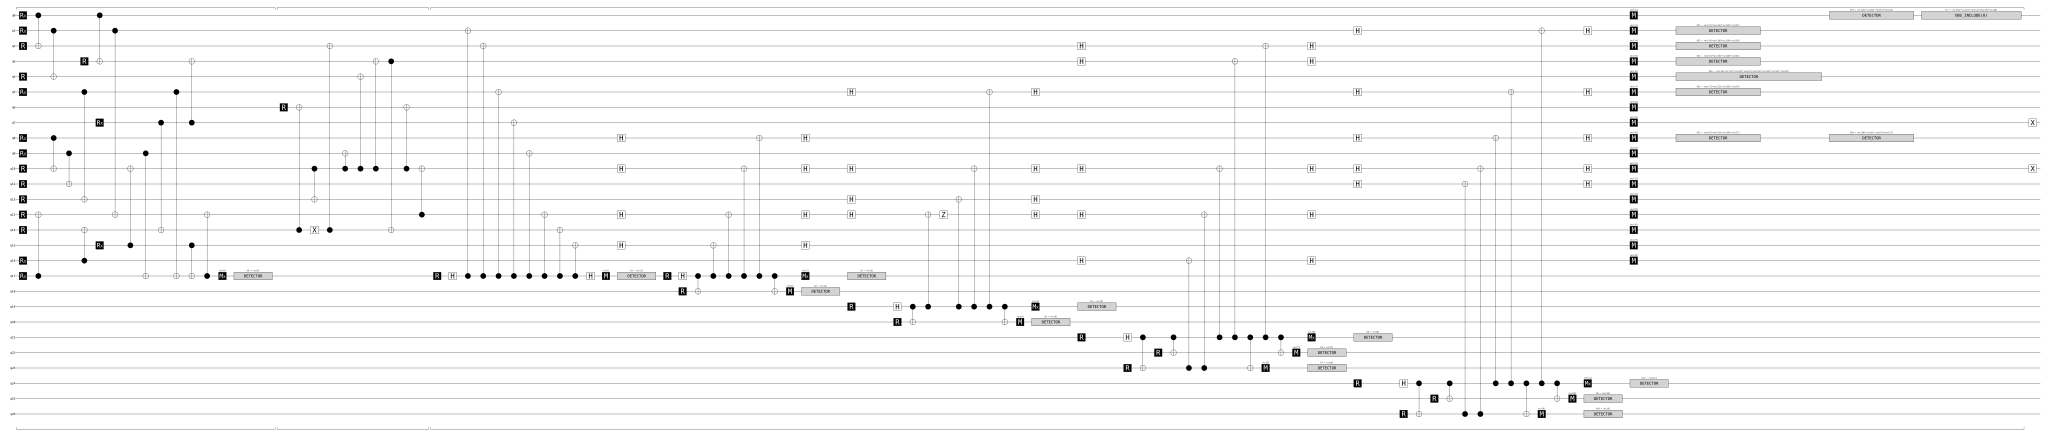

In [129]:
res_exhaustive.diagram('timeline-svg')